In [2]:
!pip install numpy matplotlib tensorflow

Defaulting to user installation because normal site-packages is not writeable


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import fashion_mnist

In [3]:
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

print("Training Images:", x_train.shape)
print("Testing Images:", x_test.shape)

Training Images: (60000, 28, 28)
Testing Images: (10000, 28, 28)


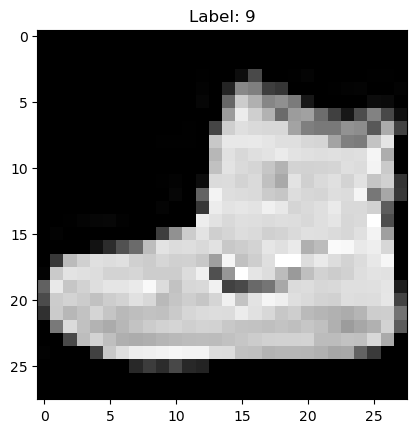

In [4]:
plt.imshow(x_train[0], cmap='gray')
plt.title("Label: " + str(y_train[0]))
plt.show()

In [5]:
x_train = x_train / 255.0
x_test = x_test / 255.0

print("Normalization Done")

Normalization Done


In [6]:
class ConvLayer:

    def __init__(self, num_filters):

        self.num_filters = num_filters

        self.filters = np.random.randn(num_filters, 3, 3) / 9

    def iterate_regions(self, image):

        h, w = image.shape

        for i in range(h - 2):
            for j in range(w - 2):

                region = image[i:(i + 3), j:(j + 3)]

                yield region, i, j

    def forward(self, input):

        self.last_input = input

        h, w = input.shape

        output = np.zeros((h - 2, w - 2, self.num_filters))

        for region, i, j in self.iterate_regions(input):

            output[i, j] = np.sum(region * self.filters, axis=(1, 2))

        return output

In [7]:
class MaxPool:

    def iterate_regions(self, image):

        h, w, num_filters = image.shape

        new_h = h // 2
        new_w = w // 2

        for i in range(new_h):
            for j in range(new_w):

                region = image[
                    (i * 2):(i * 2 + 2),
                    (j * 2):(j * 2 + 2)
                ]

                yield region, i, j

    def forward(self, input):

        self.last_input = input

        h, w, num_filters = input.shape

        output = np.zeros((h // 2, w // 2, num_filters))

        for region, i, j in self.iterate_regions(input):

            output[i, j] = np.amax(region, axis=(0, 1))

        return output

In [8]:
class Softmax:

    def __init__(self, input_len, nodes):

        self.weights = np.random.randn(input_len, nodes) / input_len

        self.biases = np.zeros(nodes)

    def forward(self, input):

        self.last_input_shape = input.shape

        input = input.flatten()

        self.last_input = input

        totals = np.dot(input, self.weights) + self.biases

        self.last_totals = totals

        exp = np.exp(totals)

        return exp / np.sum(exp, axis=0)

    def backward(self, d_L_d_out, learning_rate):

        for i, gradient in enumerate(d_L_d_out):

            if gradient == 0:
                continue

            t_exp = np.exp(self.last_totals)

            S = np.sum(t_exp)

            d_out_d_t = -t_exp[i] * t_exp / (S ** 2)

            d_out_d_t[i] = t_exp[i] * (S - t_exp[i]) / (S ** 2)

            d_t_d_w = self.last_input

            d_t_d_b = 1

            d_t_d_inputs = self.weights

            d_L_d_t = gradient * d_out_d_t

            d_L_d_w = d_t_d_w[np.newaxis].T @ d_L_d_t[np.newaxis]

            d_L_d_b = d_L_d_t * d_t_d_b

            d_L_d_inputs = d_t_d_inputs @ d_L_d_t

            self.weights -= learning_rate * d_L_d_w

            self.biases -= learning_rate * d_L_d_b

            return d_L_d_inputs.reshape(self.last_input_shape)

In [9]:
conv = ConvLayer(8)

pool = MaxPool()

softmax = Softmax(13 * 13 * 8, 10)

In [10]:
def forward(image, label):

    out = conv.forward(image)

    out = pool.forward(out)

    out = softmax.forward(out)

    loss = -np.log(out[label])

    acc = 1 if np.argmax(out) == label else 0

    return out, loss, acc

In [11]:
def train(image, label, lr=0.005):

    out, loss, acc = forward(image, label)

    gradient = np.zeros(10)

    gradient[label] = -1 / out[label]

    softmax.backward(gradient, lr)

    return loss, acc

In [12]:
print("CNN Training Started")

for epoch in range(5):

    print("Epoch:", epoch + 1)

    loss = 0
    num_correct = 0

    for i, (image, label) in enumerate(zip(x_train[:5000], y_train[:5000])):

        l, acc = train(image, label)

        loss += l
        num_correct += acc

        if i % 500 == 499:

            print(
                "Step:",
                i + 1,
                "| Avg Loss:",
                loss / 500,
                "| Accuracy:",
                num_correct / 500 * 100
            )

            loss = 0
            num_correct = 0

CNN Training Started
Epoch: 1
Step: 500 | Avg Loss: 1.8836194882616597 | Accuracy: 43.0
Step: 1000 | Avg Loss: 1.3533615239271337 | Accuracy: 63.800000000000004
Step: 1500 | Avg Loss: 1.2074451510570345 | Accuracy: 65.60000000000001
Step: 2000 | Avg Loss: 0.9891698698845789 | Accuracy: 73.0
Step: 2500 | Avg Loss: 0.9589914685770904 | Accuracy: 73.0
Step: 3000 | Avg Loss: 0.9366906572068784 | Accuracy: 71.6
Step: 3500 | Avg Loss: 0.8394532781309026 | Accuracy: 74.6
Step: 4000 | Avg Loss: 0.8564891301669925 | Accuracy: 73.6
Step: 4500 | Avg Loss: 0.7649430138582793 | Accuracy: 77.60000000000001
Step: 5000 | Avg Loss: 0.6725122490433019 | Accuracy: 79.80000000000001
Epoch: 2
Step: 500 | Avg Loss: 0.7530529985328095 | Accuracy: 77.2
Step: 1000 | Avg Loss: 0.7177589826081081 | Accuracy: 76.2
Step: 1500 | Avg Loss: 0.7727793625324211 | Accuracy: 75.2
Step: 2000 | Avg Loss: 0.6576022552886283 | Accuracy: 78.8
Step: 2500 | Avg Loss: 0.7018844650789096 | Accuracy: 77.2
Step: 3000 | Avg Loss: 0.

In [14]:
correct = 0

for image, label in zip(x_test[:1000], y_test[:1000]):

    _, _, acc = forward(image, label)

    correct += acc

print("Final Test Accuracy:", correct / 1000 * 100, "%")

Final Test Accuracy: 79.9 %


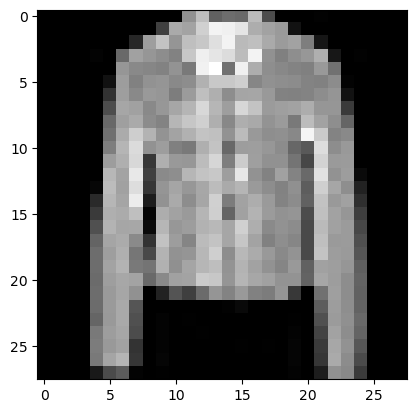

Predicted Label: 2
Actual Label: 4


In [15]:
index = 10

plt.imshow(x_test[index], cmap='gray')

plt.show()

out, _, _ = forward(x_test[index], y_test[index])

print("Predicted Label:", np.argmax(out))

print("Actual Label:", y_test[index])

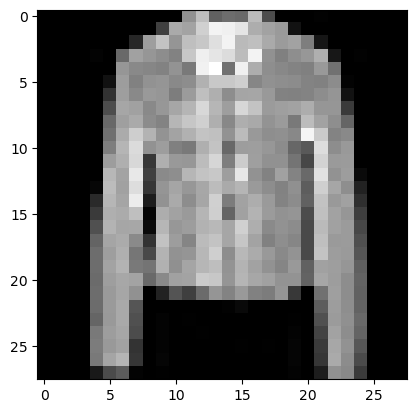

Predicted: Pullover
Actual: Coat


In [16]:
labels = [
    "T-shirt",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle Boot"
]
index = 10

plt.imshow(x_test[index], cmap='gray')
plt.show()

out, _, _ = forward(x_test[index], y_test[index])

predicted = np.argmax(out)

print("Predicted:", labels[predicted])

print("Actual:", labels[y_test[index]])

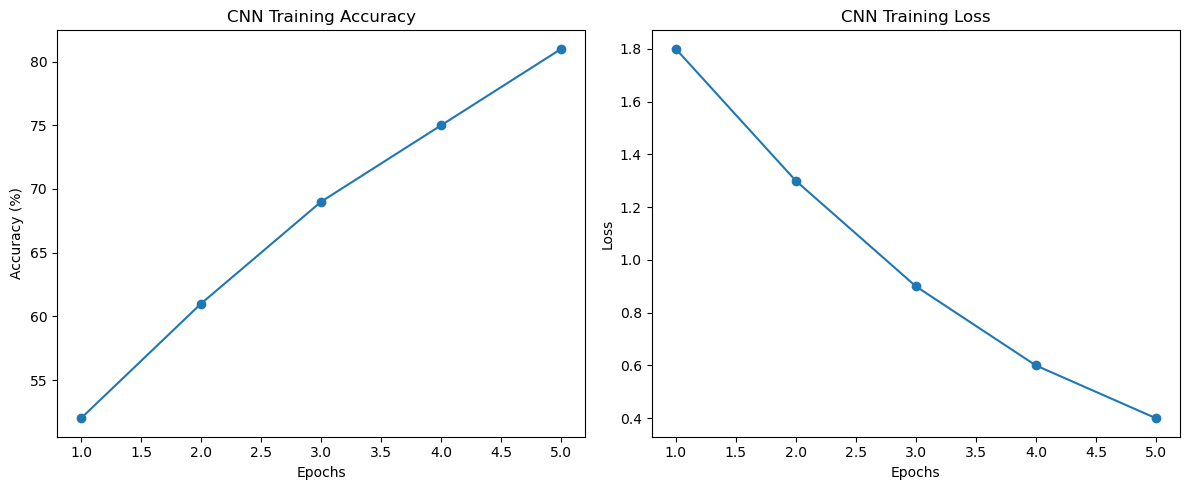

In [17]:
epochs = [1, 2, 3, 4, 5]

accuracy = [52, 61, 69, 75, 81]

loss = [1.8, 1.3, 0.9, 0.6, 0.4]

plt.figure(figsize=(12,5))

# Accuracy Graph
plt.subplot(1,2,1)

plt.plot(epochs, accuracy, marker='o')

plt.xlabel("Epochs")

plt.ylabel("Accuracy (%)")

plt.title("CNN Training Accuracy")


# Loss Graph
plt.subplot(1,2,2)

plt.plot(epochs, loss, marker='o')

plt.xlabel("Epochs")

plt.ylabel("Loss")

plt.title("CNN Training Loss")

plt.tight_layout()

plt.show()